# Linear Regression
As you may have seen in the notes computation of linear. In the notes we used the useful `sklearn` library with its `LinearRegression` class. To build your own understanding we are going to implement our own version of this class. 

## Imports
Below are some useful imports that you find in many projects. We'll explain some of these in the next section.

In [16]:
# Avoid touching these
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray # Numpy Array Type Signature
import pandas as pd
import time
from typing import Tuple

## Python List, Numpy, Pandas
Before we go into the exercises I wanted to first answer a question that comes up very often. Why are there so many different representations of a list. If you've ever programmed you have probably interacted with a list. A list allows us to store data as well as do vector and matrix operations. In Python this list is dynamically sized, meaning that we can expand it and shrink it with methods like `.append()` and `.remove()`. This permits a degree of flexibility however comes with the drawback that it is slower.

To address this a **Numpy Array** can be used instead. Numpy arrays are arrays rather than lists meaning they are one fixed sized but with the advantage they are faster. The below code illustrates this point by running additions on a list of 100,000 numbers.

<details>
  <summary>Why Numpy is Faster</summary>
    As stated above numpy arrays are faster due to their fixed size, but in addition to this they also see an increased speed as they are implemented in C rather than Python. C being a low-level language means most of its operations are much faster than those in Python. The last is parallelism, which is the ability of your computer to do multiple calculations at the same time. Numpy arrays are able to do operations on multiple elements within an array at the same time, resulting in an obvious speedup.
</details>

In [19]:
big_num = 100000

# Python's turn
start_time = time.time()
py_arr = list(range(big_num))
for _ in range(400):
    for i in range(len(py_arr)):
        py_arr[i] += py_arr[i]
print(f"Time for normal Python: {time.time() - start_time}")

# Numpy's turn
start_time = time.time()
np_arr = np.arange(big_num)
for _ in range(400):
        np_arr += np_arr # This is faster than using a seperate loop
print(f"Time for Numpy: {time.time() - start_time}")

Time for normal Python: 3.604783296585083
Time for Numpy: 0.005671977996826172


### **(Question 1)** Numpy Arrays
To practice using numpy arrays finish writing the two functions below. With the restriction that you can't use `np.mean`, `np.var`, and `np.std`. You should know the sum for mean but as a reminder variance can be computed with:

$$\text{Var}[X] = E[(X-E[X])^2]=E[X^2]-E[X]^2$$

**Implement Mean and Variance**

<details>
  <summary>Function Hints</summary>
  Remember in Numpy you can use `np.sum(...)`
</details>

In [26]:
def mean(x: np.ndarray) -> float:
    """This one should be obvious"""
    n = x.shape[0]
    #!Answer
    return np.sum(x) / n

def variance(x: np.ndarray) -> float:
    """Computes the variance of `x`"""
    #!Answer
    n = x.shape[0]
    m = mean(x)
    squared_diffs = (x - m) ** 2
    return np.sum(squared_diffs) / (n - 1)

In [36]:
x = np.array([3, 1, 4, 1, 5, 9, 2, 6])
m = np.round(mean(x), 3)
assert m == 3.875, "Expected mean(x) to be 3.875"
v = np.round(variance(x), 3)
assert v == 7.554, "Expected variance(x) to be 7.554"
print(f"Mean: {m}, Variance: {v}")

Mean: 3.875, Variance: 7.554


## Data & Pandas
Pandas is a library for allowing us to easily maniuplate data with multiple different types. Pandas use their version of a list/matrix called a dataframe. A dataframe is pretty much just a table or Python dictionary. It holds columns with names, and data which can include strings, floats, integers, or even complex objects like dates. This makes them key when dealing with most forms of data.

Below is an example of reading from a dataframe. By linking to our path we are able to create a dataframe with `pd.read_csv(...)`

In [37]:
# Get the data from the csv file
data = pd.read_csv('../data/insurance.csv')
x = data["age"].to_numpy()
y = data["charges"].to_numpy()
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


While we won't go into it this is a basic function to help plotting a graph.

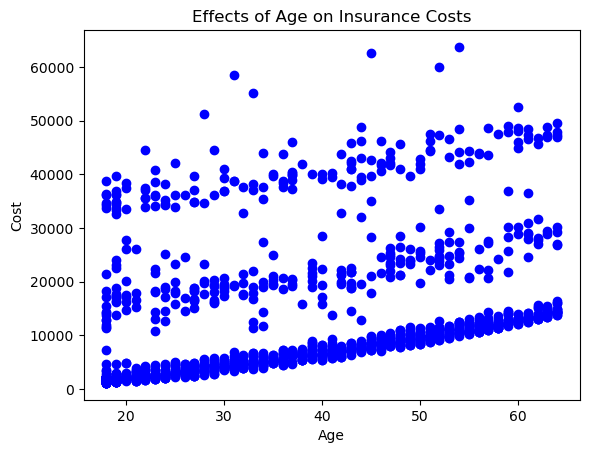

In [44]:
# Helper function to plot graphs
def plot_graph(x, y, w=None, b=None):
    if w != None and b != None:
        plt.plot(x, w * x + b, label='Your Model', color='red')
        plt.legend()
    plt.scatter(x, y, color='blue')
    plt.xlabel('Age')
    plt.ylabel('Cost')
    plt.title('Effects of Age on Insurance Costs')
    plt.show()
plot_graph(x, y)

## **(Question 2)** Analytic Methods & Least Squares 
A basic approach to solving linear regression, as seen in the notes, is an analytic method such as **least squares**. This finds the weight and bias given the x and y axis. This can be computed with:
$$w = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}$$
$$\beta = \bar{y} - w\bar{x}$$

**Implement least squares by filling in the function definition.**

<details>
  <summary>Function Hints</summary>
  Remember in Numpy you can use `np.sum(...)` and `np.mean(...)`
</details>

In [45]:
def least_squares(x: NDArray, y: NDArray) -> Tuple[float, float]:
    """
    Function to calculate the weight and biases using least squares
    Args:
        x: X-axis
        y: Y-Axis
    Params:
        Tuple representing the weight and bias
    """
    #!Answer
    # Calculate the mean of the x and y values
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    # Calculate the numerator and denominator of the slope
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
 
    # Calculate the slope and intercept
    w = numerator / denominator
    b = y_mean - w * x_mean

    return w, b

Once you've finish writing the function be sure to run the code below.

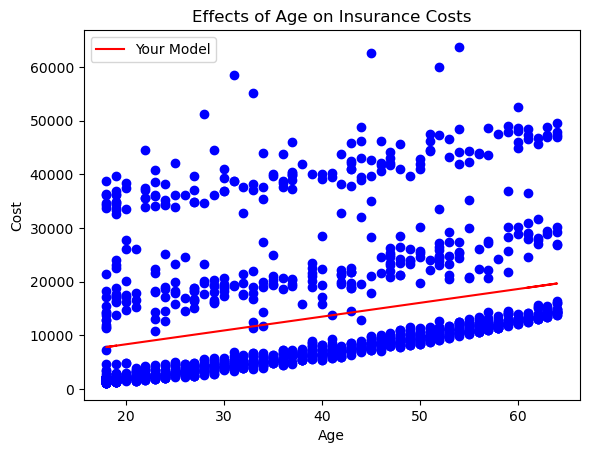

Weight: 257.7226186668955 Bias: 3165.885006063025


In [46]:
weight, bias = least_squares(x, y)
plot_graph(x, y, weight, bias)
print(f'Weight: {weight} Bias: {bias}')

## **(Question 3)** Regression & Gradient Descent
While for smaller datasets your above result may prove good enough, for larger datasets or ones with a different loss function a more generalised approach may be desired. Gradient descent is one such approach. It functions by finding the weight and bias by optimising a loss function.

Using the *least squares* loss function from before we can compute its partial derivaties with respect to $w$ and $b$ as:
$$\begin{align}
\frac{\partial \text{LSE}}{\partial w} &= -\frac{1}{N} \sum_{i=1}^{N} x_i (y_i - \hat{y}_i)\\
\frac{\partial \text{LSE}}{\partial b} &= -\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)\end{align}$$

**Implement gradient descent by filling in the below functions**
<details>
  <summary><i>Hint</i></summary>
  Gradient descent updates can be computed as:
  $$w := w - \eta \frac{\partial \text{MSE}}{\partial w}$$
$$b := b - \eta \frac{\partial \text{MSE}}{\partial b}$$
</details>

In [47]:
def gradient_descent(
    x: NDArray, 
    y: NDArray, 
    w: float, 
    b: float, 
    learning_rate: float, 
    epochs: int
) -> Tuple[float, float]:
    """
    Computes gradient descent for a linear rule
    """
    #!Answer
    n = len(y)
    for _ in range(epochs):
        # Prediction
        y_pred = w * x + b

        # Compute Gradients with respect to w and b
        dw = -(1/n) * np.sum(x * (y - y_pred))
        db = -(1/n) * np.sum(y - y_pred)

        # Update
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
    return w, b

Once you've finish writing the function be sure to run the code below. This will plot the results.

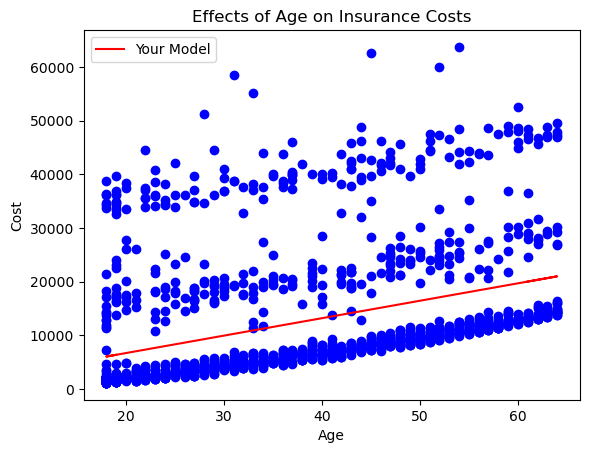

Weight: 325.1792438148059 Bias: 181.92698934097797


In [48]:
weight, bias = gradient_descent(x, y, 1, 0, 0.0005, 1000)
plot_graph(x, y, weight, bias)
print(f'Weight: {weight} Bias: {bias}')

From this you should be able to see how through using a gradient descent model a more accurate result can be provided given you tune the parameters. You should experiment with the epochs and learning rates to see how these effect your results. Tuning these values is a large part of ML and will be important to keep in mind for neural networks.

## **(Extension)** Stochastic Gradient Descent
If you have the time try to implement stochasic gradient descent. Stochastic gradient descent trains based upon a randomised batch of data, estimating the gradient rather than computing it. This can heavily reduce computational complexity at the cost of a lower convergance rate in some cases.